In [5]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
tickers = {
    "nikkei": "^N225",
    "sp500": "^GSPC"
}

start_date = "2010-01-01"
end_date = "2026-05-26"

In [7]:
data = yf.download(
    list(tickers.values()),
    start=start_date,
    end=end_date,
    auto_adjust=True
)

data.head()

[*********************100%***********************]  2 of 2 completed


Price             Close                       High                        Low  \
Ticker            ^GSPC         ^N225        ^GSPC         ^N225        ^GSPC   
2010-01-04  1132.989990  10654.790039  1133.869995  10694.490234  1116.560059   
2010-01-05  1136.520020  10681.830078  1136.630005  10791.040039  1129.660034   
2010-01-06  1137.140015  10731.450195  1139.189941  10768.610352  1133.949951   
2010-01-07  1141.689941  10681.660156  1142.459961  10774.000000  1131.319946   
2010-01-08  1144.979980  10798.320312  1145.390015  10816.450195  1136.219971   

Price                            Open                      Volume               
Ticker             ^N225        ^GSPC         ^N225         ^GSPC        ^N225  
2010-01-04  10608.139648  1116.560059  10609.339844  3.991400e+09  104400000.0  
2010-01-05  10655.570312  1132.660034  10719.440430  2.491020e+09  166200000.0  
2010-01-06  10661.169922  1135.709961  10709.549805  4.972660e+09  181800000.0  
2010-01-07  10636.669922  1136.270020  10742.750000  5.270680e+09  182600000.0  
2010-01-08  10677.559570  1140.520020  10743.299805  4.389590e+09  211800000.0

In [8]:
close_prices = data["Close"].copy()

close_prices.head()

Ticker,^GSPC,^N225
2010-01-04,1132.989990,10654.790039
2010-01-05,1136.520020,10681.830078
2010-01-06,1137.140015,10731.450195
2010-01-07,1141.689941,10681.660156
2010-01-08,1144.979980,10798.320312


In [9]:
close_prices = close_prices.rename(columns={
    "^N225": "nikkei",
    "^GSPC": "sp500"
})

close_prices.head()

Ticker,sp500,nikkei
2010-01-04,1132.989990,10654.790039
2010-01-05,1136.520020,10681.830078
2010-01-06,1137.140015,10731.450195
2010-01-07,1141.689941,10681.660156
2010-01-08,1144.979980,10798.320312


In [10]:
returns = close_prices.pct_change().dropna()

returns.head()

Ticker,sp500,nikkei
2010-01-05,0.003116,0.002538
2010-01-06,0.000546,0.004645
2010-01-07,0.004001,-0.004640
2010-01-08,0.002882,0.010922
2010-01-13,0.008326,-0.013246


In [11]:
returns.corr()

Ticker,sp500,nikkei
Ticker,,
sp500,1.000000,0.170677
nikkei,0.170677,1.000000


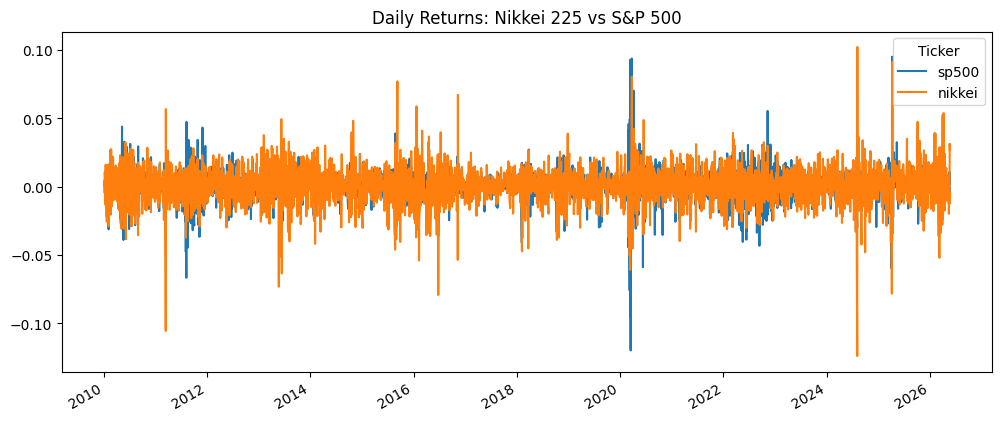

In [12]:
returns.plot(figsize=(12, 5), title="Daily Returns: Nikkei 225 vs S&P 500")
plt.show()

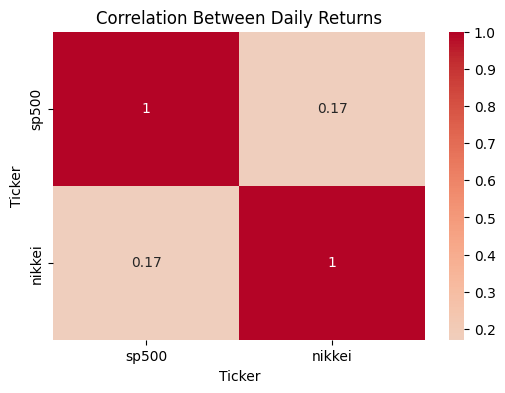

In [13]:
plt.figure(figsize=(6, 4))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between Daily Returns")
plt.show()

In [ ]:
# Note: Nikkei 225 and S&P 500 are denominated in different currencies. 
# The first analysis uses local-currency percentage returns. 
# A later extension will adjust Japanese returns into USD terms using USD/JPY exchange rate data.

## Lead-Lag Setup

Because Japan closes before the U.S. market opens on the same calendar date, Nikkei's return on date t may be known before the U.S. session on date t.

We test three simple relationships:
- Nikkei return today vs S&P 500 return today
- Nikkei return yesterday vs S&P 500 return today
- S&P 500 return yesterday vs Nikkei return today

In [14]:
lead_lag = returns.copy()

lead_lag["nikkei_lag1"] = lead_lag["nikkei"].shift(1)
lead_lag["sp500_lag1"] = lead_lag["sp500"].shift(1)

lead_lag = lead_lag.dropna()

lead_lag.head()

Ticker,sp500,nikkei,nikkei_lag1,sp500_lag1
2010-01-06,0.000546,0.004645,0.002538,0.003116
2010-01-07,0.004001,-0.004640,0.004645,0.000546
2010-01-08,0.002882,0.010922,-0.004640,0.004001
2010-01-13,0.008326,-0.013246,0.010922,0.002882
2010-01-14,0.002426,0.016083,-0.013246,0.008326


In [15]:
lag_corr = lead_lag[[
    "nikkei",
    "sp500",
    "nikkei_lag1",
    "sp500_lag1"
]].corr()

lag_corr

Ticker,nikkei,sp500,nikkei_lag1,sp500_lag1
Ticker,,,,
nikkei,1.000000,0.170668,-0.062601,0.414040
sp500,0.170668,1.000000,0.037944,-0.118615
nikkei_lag1,-0.062601,0.037944,1.000000,0.170613
sp500_lag1,0.414040,-0.118615,0.170613,1.000000


In [16]:
relationships = {
    "Nikkei today vs S&P today": lead_lag["nikkei"].corr(lead_lag["sp500"]),
    "Nikkei yesterday vs S&P today": lead_lag["nikkei_lag1"].corr(lead_lag["sp500"]),
    "S&P yesterday vs Nikkei today": lead_lag["sp500_lag1"].corr(lead_lag["nikkei"]),
}

pd.Series(relationships).sort_values(ascending=False)

S&P yesterday vs Nikkei today    0.414040
Nikkei today vs S&P today        0.170668
Nikkei yesterday vs S&P today    0.037944
dtype: float64

## Timeline-Aware Lead-Lag Dataset

We build two prediction datasets:

1. Japan -> U.S.: Nikkei return on date t is known before the U.S. market opens on date t.
2. U.S. -> Japan: S&P 500 return from the previous U.S. session is known before Japan opens on date t.

This avoids a major beginner mistake: using information that would not have been available at trade time.

In [17]:
returns_clean = returns.copy().sort_index()

jp = returns_clean[["nikkei"]].dropna().reset_index()
us = returns_clean[["sp500"]].dropna().reset_index()

jp.columns = ["date", "nikkei_return"]
us.columns = ["date", "sp500_return"]

us_from_japan = pd.merge(
    us.rename(columns={"sp500_return": "target_sp500"}),
    jp.rename(columns={"nikkei_return": "feature_nikkei_same_day"}),
    on="date",
    how="inner"
)

japan_from_us = pd.merge_asof(
    jp.rename(columns={"date": "japan_date", "nikkei_return": "target_nikkei"}).sort_values("japan_date"),
    us.rename(columns={"date": "us_date", "sp500_return": "feature_sp500_previous"}).sort_values("us_date"),
    left_on="japan_date",
    right_on="us_date",
    direction="backward",
    allow_exact_matches=False
).dropna()

print("Japan -> U.S. rows:", len(us_from_japan))
print("U.S. -> Japan rows:", len(japan_from_us))

Japan -> U.S. rows: 3540
U.S. -> Japan rows: 3539


In [18]:
directional_corr = pd.Series({
    "Japan -> U.S.": us_from_japan["feature_nikkei_same_day"].corr(us_from_japan["target_sp500"]),
    "U.S. -> Japan": japan_from_us["feature_sp500_previous"].corr(japan_from_us["target_nikkei"]),
})

directional_corr

Japan -> U.S.    0.170677
U.S. -> Japan    0.414040
dtype: float64

In [22]:
import statsmodels.api as sm

def regression_summary(df, feature_col, target_col):
    X = sm.add_constant(df[feature_col])
    y = df[target_col]
    model = sm.OLS(y, X).fit()
    
    return pd.Series({
        "coefficient": model.params[feature_col],
        "p_value": model.pvalues[feature_col],
        "r_squared": model.rsquared,
        "observations": int(model.nobs)
    })

reg_results = pd.DataFrame({
    "Japan -> U.S.": regression_summary(us_from_japan, "feature_nikkei_same_day", "target_sp500"),
    "U.S. -> Japan": regression_summary(japan_from_us, "feature_sp500_previous", "target_nikkei"),
}).T

reg_results

,coefficient,p_value,r_squared,observations
Japan -> U.S.,0.138828,1.509763e-24,0.029131,3540.0
U.S. -> Japan,0.509030,1.191616e-146,0.171429,3539.0


In [23]:
def train_test_backtest(df, feature_col, target_col, split=0.7, cost_bps=5):
    df = df.copy().sort_index()
    split_idx = int(len(df) * split)

    train = df.iloc[:split_idx]
    test = df.iloc[split_idx:].copy()

    X_train = sm.add_constant(train[feature_col])
    y_train = train[target_col]

    model = sm.OLS(y_train, X_train).fit()

    X_test = sm.add_constant(test[feature_col])
    test["predicted_return"] = model.predict(X_test)

    test["signal"] = np.where(test["predicted_return"] > 0, 1, 0)
    test["turnover"] = test["signal"].diff().abs().fillna(0)
    test["cost"] = test["turnover"] * (cost_bps / 10000)

    test["strategy_return"] = test["signal"] * test[target_col] - test["cost"]
    test["buy_hold_return"] = test[target_col]

    return test, model

bt_japan_from_us, model_japan_from_us = train_test_backtest(
    japan_from_us,
    "feature_sp500_previous",
    "target_nikkei"
)

bt_japan_from_us[["target_nikkei", "predicted_return", "signal", "strategy_return", "buy_hold_return"]].head()

,target_nikkei,predicted_return,signal,strategy_return,buy_hold_return
2478,-0.001919,-0.000296,0,-0.000000,-0.001919
2479,-0.003548,0.000164,1,-0.004048,-0.003548
2480,0.003387,-0.000781,0,-0.000500,0.003387
2481,-0.000339,0.002279,1,-0.000839,-0.000339
2482,0.007360,0.001002,1,0.007360,0.007360


In [24]:
def performance_stats(returns_series, periods_per_year=252):
    r = returns_series.dropna()
    equity = (1 + r).cumprod()

    total_return = equity.iloc[-1] - 1
    annual_return = equity.iloc[-1] ** (periods_per_year / len(r)) - 1
    annual_volatility = r.std() * np.sqrt(periods_per_year)
    sharpe = annual_return / annual_volatility if annual_volatility != 0 else np.nan
    max_drawdown = (equity / equity.cummax() - 1).min()

    return pd.Series({
        "total_return": total_return,
        "annual_return": annual_return,
        "annual_volatility": annual_volatility,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "win_rate": (r > 0).mean()
    })

pd.DataFrame({
    "Strategy": performance_stats(bt_japan_from_us["strategy_return"]),
    "Buy & Hold": performance_stats(bt_japan_from_us["buy_hold_return"]),
})

,Strategy,Buy & Hold
total_return,10.035454,0.754853
annual_return,0.767835,0.142761
annual_volatility,0.149918,0.225565
sharpe,5.121688,0.632905
max_drawdown,-0.061285,-0.280217
win_rate,0.363465,0.526365


## Tradability Check

The earlier backtest used Nikkei close-to-close returns. This is useful for studying predictability, but it is not fully tradable because part of the close-to-close move may happen before a trader can enter after observing the U.S. close.

To make the backtest more realistic, we use Nikkei open-to-close returns as the trading target.

In [25]:
open_prices = data["Open"].rename(columns={
    "^N225": "nikkei",
    "^GSPC": "sp500"
})

close_prices = data["Close"].rename(columns={
    "^N225": "nikkei",
    "^GSPC": "sp500"
})

nikkei_open_to_close = (
    close_prices["nikkei"] / open_prices["nikkei"] - 1
).dropna()

sp500_close_to_close = close_prices["sp500"].pct_change().dropna()

In [26]:
jp_trading = nikkei_open_to_close.reset_index()
jp_trading.columns = ["japan_date", "target_nikkei_open_to_close"]

us_signal = sp500_close_to_close.reset_index()
us_signal.columns = ["us_date", "feature_sp500_previous_close_to_close"]

japan_tradable = pd.merge_asof(
    jp_trading.sort_values("japan_date"),
    us_signal.sort_values("us_date"),
    left_on="japan_date",
    right_on="us_date",
    direction="backward",
    allow_exact_matches=False
).dropna()

japan_tradable.head()

,japan_date,target_nikkei_open_to_close,us_date,feature_sp500_previous_close_to_close
2,2010-01-06,0.002045,2010-01-05,0.003116
3,2010-01-07,-0.005687,2010-01-06,0.000546
4,2010-01-08,0.005121,2010-01-07,0.004001
5,2010-01-12,0.010101,2010-01-11,0.001747
6,2010-01-13,-0.005600,2010-01-12,-0.009381


In [27]:
regression_summary(
    japan_tradable,
    "feature_sp500_previous_close_to_close",
    "target_nikkei_open_to_close"
)

coefficient     8.744336e-02
p_value         2.801951e-10
r_squared       9.898948e-03
observations    4.004000e+03
dtype: float64

In [30]:
def train_test_backtest(df, feature_col, target_col, split=0.7, cost_bps=5):
    df = df.copy().sort_values(df.columns[0])
    split_idx = int(len(df) * split)

    train = df.iloc[:split_idx]
    test = df.iloc[split_idx:].copy()

    X_train = sm.add_constant(train[feature_col])
    y_train = train[target_col]
    model = sm.OLS(y_train, X_train).fit()

    X_test = sm.add_constant(test[feature_col])
    test["predicted_return"] = model.predict(X_test)

    test["signal"] = np.where(test["predicted_return"] > 0, 1, 0)

    test["turnover"] = test["signal"].diff().abs()
    test.loc[test.index[0], "turnover"] = abs(test.loc[test.index[0], "signal"])

    test["cost"] = test["turnover"] * (cost_bps / 10000)
    test["strategy_return"] = test["signal"] * test[target_col] - test["cost"]
    test["buy_hold_return"] = test[target_col]

    return test, model

In [31]:
bt_japan_tradable, model_japan_tradable = train_test_backtest(
    japan_tradable,
    "feature_sp500_previous_close_to_close",
    "target_nikkei_open_to_close"
)

pd.DataFrame({
    "Strategy": performance_stats(bt_japan_tradable["strategy_return"]),
    "Buy & Hold": performance_stats(bt_japan_tradable["buy_hold_return"]),
}).T

,total_return,annual_return,annual_volatility,sharpe,max_drawdown,win_rate
Strategy,0.359823,0.066558,0.092088,0.722766,-0.094992,0.206323
Buy & Hold,0.181569,0.035598,0.156205,0.227891,-0.288640,0.496672


In [32]:
sp500_open_to_close = (
    close_prices["sp500"] / open_prices["sp500"] - 1
).dropna()

us_signal_open_close = sp500_open_to_close.reset_index()
us_signal_open_close.columns = ["us_date", "feature_sp500_open_to_close"]

japan_tradable_oc_signal = pd.merge_asof(
    jp_trading.sort_values("japan_date"),
    us_signal_open_close.sort_values("us_date"),
    left_on="japan_date",
    right_on="us_date",
    direction="backward",
    allow_exact_matches=False
).dropna()

regression_summary(
    japan_tradable_oc_signal,
    "feature_sp500_open_to_close",
    "target_nikkei_open_to_close"
)

coefficient     1.201537e-01
p_value         2.721621e-13
r_squared       1.325294e-02
observations    4.005000e+03
dtype: float64

In [33]:
bt_japan_from_us_oc, model_japan_from_us_oc = train_test_backtest(
    japan_tradable_oc_signal,
    "feature_sp500_open_to_close",
    "target_nikkei_open_to_close"
)

pd.DataFrame({
    "US Close-to-Close Signal": performance_stats(bt_japan_tradable["strategy_return"]),
    "US Open-to-Close Signal": performance_stats(bt_japan_from_us_oc["strategy_return"]),
    "Buy & Hold": performance_stats(bt_japan_from_us_oc["buy_hold_return"]),
}).T

,total_return,annual_return,annual_volatility,sharpe,max_drawdown,win_rate
US Close-to-Close Signal,0.359823,0.066558,0.092088,0.722766,-0.094992,0.206323
US Open-to-Close Signal,0.381843,0.070156,0.103691,0.676587,-0.133831,0.211314
Buy & Hold,0.181569,0.035598,0.156205,0.227891,-0.288640,0.496672


## Stability Across Time

A strategy can look good in one train/test split by luck. To check stability, we evaluate performance by calendar year during the test period.

In [34]:
def yearly_performance(bt, date_col, strategy_col="strategy_return", benchmark_col="buy_hold_return"):
    yearly = bt.copy()
    yearly["year"] = pd.to_datetime(yearly[date_col]).dt.year

    rows = []

    for year, group in yearly.groupby("year"):
        strategy_stats = performance_stats(group[strategy_col], periods_per_year=252)
        benchmark_stats = performance_stats(group[benchmark_col], periods_per_year=252)

        rows.append({
            "year": year,
            "strategy_return": strategy_stats["total_return"],
            "benchmark_return": benchmark_stats["total_return"],
            "strategy_sharpe": strategy_stats["sharpe"],
            "benchmark_sharpe": benchmark_stats["sharpe"],
            "strategy_max_drawdown": strategy_stats["max_drawdown"],
            "benchmark_max_drawdown": benchmark_stats["max_drawdown"],
        })

    return pd.DataFrame(rows)

yearly_close_close = yearly_performance(bt_japan_tradable, "japan_date")
yearly_open_close = yearly_performance(bt_japan_from_us_oc, "japan_date")

yearly_open_close

,year,strategy_return,benchmark_return,strategy_sharpe,benchmark_sharpe,strategy_max_drawdown,benchmark_max_drawdown
0,2021,-0.108710,-0.060867,-2.209864,-0.962507,-0.133831,-0.110456
1,2022,0.112633,-0.034898,1.477449,-0.279204,-0.049068,-0.105755
2,2023,0.029070,0.111610,0.415564,1.073795,-0.056599,-0.053230
3,2024,0.114299,0.034154,1.026234,0.176504,-0.062565,-0.184615
4,2025,0.039372,-0.055454,0.366899,-0.348314,-0.077112,-0.200142
5,2026,0.169151,0.200598,3.033104,2.970385,-0.050198,-0.067431


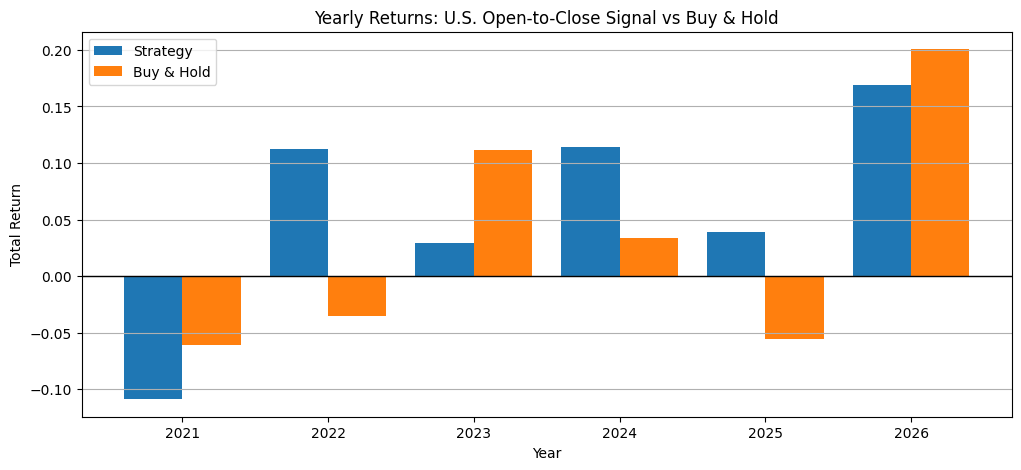

In [35]:
plt.figure(figsize=(12, 5))
plt.bar(
    yearly_open_close["year"] - 0.2,
    yearly_open_close["strategy_return"],
    width=0.4,
    label="Strategy"
)
plt.bar(
    yearly_open_close["year"] + 0.2,
    yearly_open_close["benchmark_return"],
    width=0.4,
    label="Buy & Hold"
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Yearly Returns: U.S. Open-to-Close Signal vs Buy & Hold")
plt.xlabel("Year")
plt.ylabel("Total Return")
plt.legend()
plt.grid(True, axis="y")
plt.show()

In [36]:
yearly_open_close[["year", "strategy_return", "benchmark_return"]]

,year,strategy_return,benchmark_return
0,2021,-0.108710,-0.060867
1,2022,0.112633,-0.034898
2,2023,0.029070,0.111610
3,2024,0.114299,0.034154
4,2025,0.039372,-0.055454
5,2026,0.169151,0.200598


In [37]:
combined_comparison = pd.DataFrame({
    "US Close-to-Close Signal": performance_stats(bt_japan_tradable["strategy_return"]),
    "US Open-to-Close Signal": performance_stats(bt_japan_from_us_oc["strategy_return"]),
    "Buy & Hold": performance_stats(bt_japan_from_us_oc["buy_hold_return"]),
}).T

combined_comparison

,total_return,annual_return,annual_volatility,sharpe,max_drawdown,win_rate
US Close-to-Close Signal,0.359823,0.066558,0.092088,0.722766,-0.094992,0.206323
US Open-to-Close Signal,0.381843,0.070156,0.103691,0.676587,-0.133831,0.211314
Buy & Hold,0.181569,0.035598,0.156205,0.227891,-0.288640,0.496672


## Signal Definition Comparison

Two U.S. signal definitions are tested:

1. Close-to-close return: captures the full daily U.S. move, including overnight effects.
2. Open-to-close return: captures only the U.S. regular trading session.

The target is kept as Japan open-to-close return, which represents the tradable Japanese session after the U.S. signal is known.